# Probabilistic Power Price Forecasting


> Built probabilistic deep-learning models for 24-hour electricity price forecasting, comparing QR-DNN, Normal-DNN and Johnson SU-DNN specifications. Evaluated predictive distributions using Pinball loss and Winkler score; produced upside/downside price bands for scenario analysis and risk-aware trading decisions.

This notebook uses the existing recalibration engine and existing model classes. It does not rely on the earlier helper script.


## 1. Setup

In [1]:
from pathlib import Path
import os
import sys
import pickle
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "Electricity_Price_Load_Forecasting_3":
    candidate = PROJECT_DIR / "Electricity_Price_Load_Forecasting_3"
    if candidate.exists():
        PROJECT_DIR = candidate

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))

from tools.PrTSF_Recalib_tools import PrTsfRecalibEngine, load_data_model_configs

PROJECT_DIR

WindowsPath('c:/Users/andre/git_repos/Projects/Electricity_Price_Load_Forecasting_3')

## 2. Controls

In [2]:
TASK_NAME = "EM_price"
RUN_RECALIBRATION = False
OUTPUT_DIR = PROJECT_DIR / "experiments" / "tasks" / TASK_NAME / "probabilistic_summary"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROB_EXPERIMENTS = [
    {"label": "QR-DNN", "setup": "QR-DNN", "run_id": "recalib_opt_random_1_2"},
    {"label": "Normal-DNN", "setup": "N-DNN", "run_id": "recalib_opt_random_1_2"},
    {"label": "Johnson SU-DNN", "setup": "JSU-DNN", "run_id": "recalib_opt_random_1_2"},
]

OUTPUT_DIR

WindowsPath('c:/Users/andre/git_repos/Projects/Electricity_Price_Load_Forecasting_3/experiments/tasks/EM_price/probabilistic_summary')

## 3. Helper functions

In [ ]:
def get_pred_horizon(configs: Dict) -> int:
    if "pred_horiz" in configs["model_config"]:
        return int(configs["model_config"]["pred_horiz"])
    return int(configs["data_config"].pred_horiz)


def build_target_quantiles(target_alpha: List[float]) -> List[float]:
    qs = [0.5]
    for alpha in target_alpha:
        qs.append(alpha / 2)
        qs.append(1 - alpha / 2)
    return sorted(qs)


def result_pickle_path(task_name: str, exper_setup: str, run_id: str, optuna_m: str) -> Path:
    return (
        PROJECT_DIR
        / "experiments"
        / "tasks"
        / task_name
        / exper_setup
        / run_id
        / "results"
        / f"recalib_test_results-tuned-{optuna_m}.p"
    )


def load_or_run_experiment(label: str, exper_setup: str, run_id: str):
    configs = load_data_model_configs(task_name=TASK_NAME, exper_setup=exper_setup, run_id=run_id)
    optuna_m = configs["model_config"]["optuna_m"]
    result_path = result_pickle_path(TASK_NAME, exper_setup, run_id, optuna_m)

    if result_path.exists() and not RUN_RECALIBRATION:
        print(f"[{label}] loading saved results: {result_path}")
        with open(result_path, "rb") as f:
            return pickle.load(f), configs

    if not RUN_RECALIBRATION:
        print(f"[{label}] missing results: {result_path}")
        print("Set RUN_RECALIBRATION=True and rerun this cell to train/recalibrate.")
        return None, configs

    print(f"[{label}] running recalibration. This may take time.")
    dataset_path = PROJECT_DIR / "data" / "datasets" / configs["data_config"].dataset_name
    ds = pd.read_csv(dataset_path)

    engine = PrTsfRecalibEngine(
        dataset=ds,
        data_configs=configs["data_config"],
        model_configs=configs["model_config"],
    )
    model_hyperparams = engine.get_model_hyperparams(
        method="load_tuned",
        optuna_m=configs["model_config"]["optuna_m"],
    )
    preds = engine.run_recalibration(
        model_hyperparams=model_hyperparams,
        plot_history=False,
        plot_weights=False,
    )
    return preds, configs


def get_target_col(df: pd.DataFrame) -> str:
    if TASK_NAME in df.columns:
        return TASK_NAME
    if f"TARG__{TASK_NAME}" in df.columns:
        return f"TARG__{TASK_NAME}"
    raise KeyError(f"Cannot find target column in {list(df.columns)}")


def quantile_columns(df: pd.DataFrame, qs: List[float]) -> List:
    cols = []
    for q in qs:
        if q in df.columns:
            cols.append(q)
        elif str(q) in df.columns:
            cols.append(str(q))
        else:
            raise KeyError(f"Missing quantile column q={q}")
    return cols


def compute_pinball_scores(y_true: np.ndarray, pred_quantiles: np.ndarray, quantiles_levels: List[float]) -> np.ndarray:
    score = []
    for i, q in enumerate(quantiles_levels):
        error = y_true - pred_quantiles[:, :, i]
        loss_q = np.maximum(q * error, (q - 1) * error)
        score.append(np.expand_dims(loss_q, -1))
    return np.mean(np.concatenate(score, axis=-1), axis=0)


def compute_winkler_scores(y_true: np.ndarray, pred_quantiles: np.ndarray, quantiles_levels: List[float]) -> Tuple[np.ndarray, List[float]]:
    score = []
    lower_quantiles = quantiles_levels[: len(quantiles_levels) // 2]
    for i, tau in enumerate(lower_quantiles):
        lower = pred_quantiles[:, :, i]
        upper = pred_quantiles[:, :, -i - 1]
        alpha = 2 * tau
        width = upper - lower
        below_lower = np.maximum(lower - y_true, 0)
        above_upper = np.maximum(y_true - upper, 0)
        interval_score = width + 2 / alpha * (below_lower + above_upper)
        score.append(np.expand_dims(interval_score, -1))
    return np.mean(np.concatenate(score, axis=-1), axis=0), lower_quantiles


def score_probabilistic_model(label: str, preds: pd.DataFrame, configs: Dict) -> Dict:
    pred_h = get_pred_horizon(configs)
    qs = build_target_quantiles(configs["model_config"]["target_alpha"])
    target_col = get_target_col(preds)
    q_cols = quantile_columns(preds, qs)

    y_true = preds[target_col].to_numpy().reshape(-1, pred_h)
    pred_q = preds[q_cols].to_numpy().reshape(-1, pred_h, len(qs))

    pinball = compute_pinball_scores(y_true, pred_q, qs)
    winkler, lower_qs = compute_winkler_scores(y_true, pred_q, qs)

    pinball_df = pd.DataFrame(pinball, columns=[f"q_{q:g}" for q in qs], index=[f"Hour {i+1}" for i in range(pred_h)])
    winkler_df = pd.DataFrame(winkler, columns=[f"PI_{q:g}_{1-q:g}" for q in lower_qs], index=[f"Hour {i+1}" for i in range(pred_h)])

    safe = label.replace(" ", "_").replace("-", "_")
    pinball_df.to_csv(OUTPUT_DIR / f"{safe}_pinball_by_hour_quantile.csv")
    winkler_df.to_csv(OUTPUT_DIR / f"{safe}_winkler_by_hour_interval.csv")

    bands = build_price_bands(preds, qs)
    bands.to_csv(OUTPUT_DIR / f"{safe}_price_bands.csv")

    return {
        "model": label,
        "PF_method": configs["model_config"]["PF_method"],
        "avg_pinball_loss": float(np.mean(pinball)),
        "avg_winkler_score": float(np.mean(winkler)),
        "median_pinball_loss": float(np.median(pinball)),
        "median_winkler_score": float(np.median(winkler)),
        "pred_horizon_hours": pred_h,
    }


def build_price_bands(preds: pd.DataFrame, qs: List[float]) -> pd.DataFrame:
    target_col = get_target_col(preds)

    def qcol(q):
        if q in preds.columns:
            return q
        if str(q) in preds.columns:
            return str(q)
        raise KeyError(q)

    lower_q = 0.05 if 0.05 in qs else qs[0]
    upper_q = 0.95 if 0.95 in qs else qs[-1]

    out = pd.DataFrame(index=preds.index)
    out["realized_price"] = preds[target_col]
    out["median_price"] = preds[qcol(0.5)]
    out[f"downside_q_{lower_q:g}"] = preds[qcol(lower_q)]
    out[f"upside_q_{upper_q:g}"] = preds[qcol(upper_q)]
    out["downside_risk_vs_median"] = out["median_price"] - out[f"downside_q_{lower_q:g}"]
    out["upside_potential_vs_median"] = out[f"upside_q_{upper_q:g}"] - out["median_price"]
    out["band_width"] = out[f"upside_q_{upper_q:g}"] - out[f"downside_q_{lower_q:g}"]
    return out


## 4. Load/run QR-DNN, Normal-DNN and Johnson SU-DNN

In [4]:
predictions = {}
configs_by_model = {}

for exp in PROB_EXPERIMENTS:
    preds, conf = load_or_run_experiment(exp["label"], exp["setup"], exp["run_id"])
    if preds is not None:
        predictions[exp["label"]] = preds
    configs_by_model[exp["label"]] = conf

list(predictions.keys())

[QR-DNN] loading saved results: c:\Users\andre\git_repos\Projects\Electricity_Price_Load_Forecasting_3\experiments\tasks\EM_price\QR-DNN\recalib_opt_random_1_2\results\recalib_test_results-tuned-random.p
[Normal-DNN] loading saved results: c:\Users\andre\git_repos\Projects\Electricity_Price_Load_Forecasting_3\experiments\tasks\EM_price\N-DNN\recalib_opt_random_1_2\results\recalib_test_results-tuned-random.p
[Johnson SU-DNN] loading saved results: c:\Users\andre\git_repos\Projects\Electricity_Price_Load_Forecasting_3\experiments\tasks\EM_price\JSU-DNN\recalib_opt_random_1_2\results\recalib_test_results-tuned-random.p


['QR-DNN', 'Normal-DNN', 'Johnson SU-DNN']

## 5. Pinball and Winkler comparison

In [5]:
summary_rows = []
for label, preds in predictions.items():
    summary_rows.append(score_probabilistic_model(label, preds, configs_by_model[label]))

prob_summary = pd.DataFrame(summary_rows).sort_values("avg_pinball_loss")
prob_summary.to_csv(OUTPUT_DIR / "model_comparison_pinball_winkler.csv", index=False)
prob_summary

,model,PF_method,avg_pinball_loss,avg_winkler_score,median_pinball_loss,median_winkler_score,pred_horizon_hours
2,Johnson SU-DNN,JSU,0.277099,17.226472,0.229387,16.777863,24
1,Normal-DNN,Normal,0.284975,17.692331,0.242023,17.278588,24
0,QR-DNN,qr,0.331808,20.413518,0.263289,20.323771,24


## 6. Best model price bands

In [6]:
best_model = prob_summary.iloc[0]["model"]
best_qs = build_target_quantiles(configs_by_model[best_model]["model_config"]["target_alpha"])
best_bands = build_price_bands(predictions[best_model], best_qs)
best_bands.to_csv(OUTPUT_DIR / "best_model_price_bands.csv")

print(f"Best model by average Pinball loss: {best_model}")
best_bands.head()

Best model by average Pinball loss: Johnson SU-DNN


,realized_price,median_price,downside_q_0.05,upside_q_0.95,downside_risk_vs_median,upside_potential_vs_median,band_width
Datetime,,,,,,,
2017-05-01 00:00:00,34.50,33.959043,25.886416,41.928350,8.072627,7.969307,16.041934
2017-05-01 01:00:00,29.18,30.644746,25.240382,36.212902,5.404364,5.568156,10.972520
2017-05-01 02:00:00,29.20,30.178598,23.180913,37.051181,6.997685,6.872582,13.870267
2017-05-01 03:00:00,29.15,29.733465,22.434890,37.371753,7.298574,7.638288,14.936863
2017-05-01 04:00:00,29.23,29.019009,21.550843,35.878532,7.468166,6.859523,14.327689


## 7. Visual check

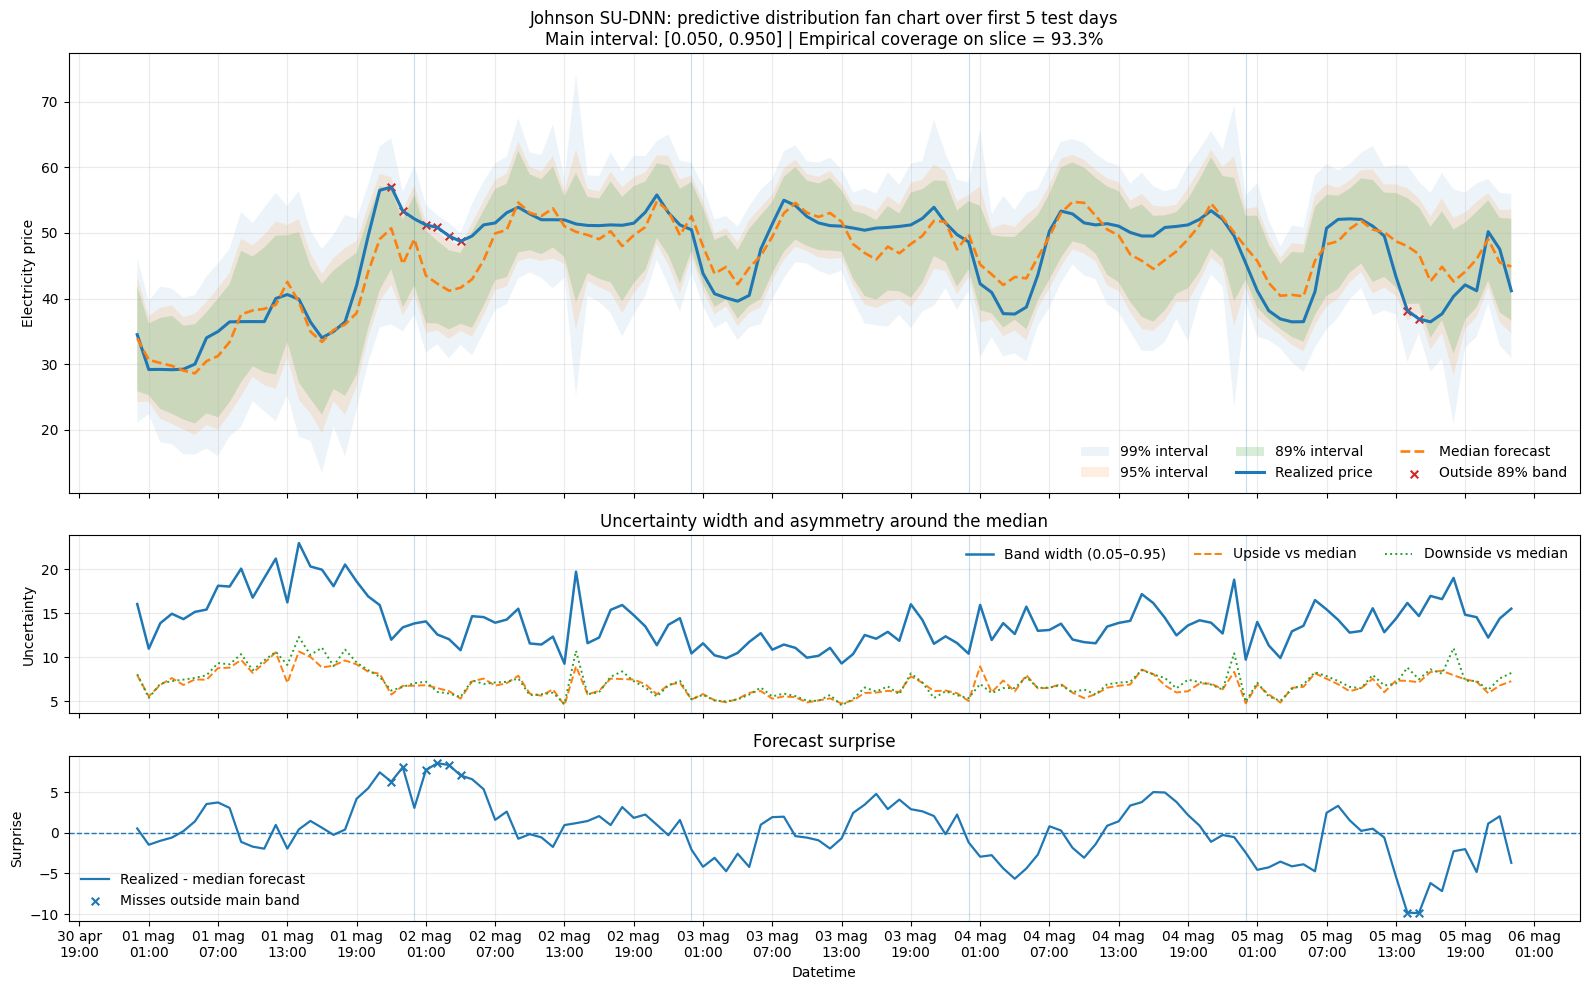

In [11]:
import matplotlib.dates as mdates


# -----------------------------------
# 1. Use the full quantile predictions
# -----------------------------------
plot_df = predictions[best_model].iloc[:24 * 5].copy()
plot_df.index = pd.to_datetime(plot_df.index)

target_col = get_target_col(plot_df)
quantiles = build_target_quantiles(
    configs_by_model[best_model]["model_config"]["target_alpha"]
)

def qcol(q):
    if q in plot_df.columns:
        return q
    if str(q) in plot_df.columns:
        return str(q)
    raise KeyError(f"Missing quantile column for q={q}")

# Candidate central intervals to display
candidate_intervals = [
    (0.25, 0.75),   # 50%
    (0.10, 0.90),   # 80%
    (0.05, 0.95),   # 90%
    (0.025, 0.975), # 95%
    (0.005, 0.995), # 99%
]

intervals = [
    (l, u) for (l, u) in candidate_intervals
    if l in quantiles and u in quantiles
]

median_col = qcol(0.5)

# -----------------------------------
# 2. Key series
# -----------------------------------
realized = plot_df[target_col]
median = plot_df[median_col]

# Use 90% band as main diagnostic band if available
main_lower_q = 0.05 if 0.05 in quantiles else intervals[0][0]
main_upper_q = 0.95 if 0.95 in quantiles else intervals[0][1]

lower_main = plot_df[qcol(main_lower_q)]
upper_main = plot_df[qcol(main_upper_q)]

band_width = upper_main - lower_main
upside = upper_main - median
downside = median - lower_main
surprise = realized - median

inside_main = (realized >= lower_main) & (realized <= upper_main)
coverage_main = inside_main.mean() * 100

# -----------------------------------
# 3. Plot
# -----------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.3, 1.2]}
)

ax_top, ax_mid, ax_bot = axes

# -------------------------
# Top: fan chart
# -------------------------
# Plot widest intervals first, then narrower ones on top
for i, (lq, uq) in enumerate(reversed(intervals)):
    alpha = 0.08 + 0.05 * i
    ax_top.fill_between(
        plot_df.index,
        plot_df[qcol(lq)],
        plot_df[qcol(uq)],
        alpha=alpha,
        label=f"{int((uq - lq) * 100)}% interval"
    )

ax_top.plot(
    plot_df.index,
    realized,
    linewidth=2.2,
    label="Realized price"
)

ax_top.plot(
    plot_df.index,
    median,
    linewidth=1.9,
    linestyle="--",
    label="Median forecast"
)

# Highlight misses outside the main interval
outside = ~inside_main
ax_top.scatter(
    plot_df.index[outside],
    realized[outside],
    s=30,
    marker="x",
    label=f"Outside {int((main_upper_q - main_lower_q) * 100)}% band"
)

ax_top.set_title(
    f"{best_model}: predictive distribution fan chart over first 5 test days\n"
    f"Main interval: [{main_lower_q:.3f}, {main_upper_q:.3f}] | "
    f"Empirical coverage on slice = {coverage_main:.1f}%"
)
ax_top.set_ylabel("Electricity price")
ax_top.grid(True, alpha=0.25)
ax_top.legend(ncol=3, frameon=False)

# -------------------------
# Middle: uncertainty shape
# -------------------------
ax_mid.plot(
    plot_df.index,
    band_width,
    linewidth=1.8,
    label=f"Band width ({main_lower_q:.2f}–{main_upper_q:.2f})"
)

ax_mid.plot(
    plot_df.index,
    upside,
    linewidth=1.4,
    linestyle="--",
    label="Upside vs median"
)

ax_mid.plot(
    plot_df.index,
    downside,
    linewidth=1.4,
    linestyle=":",
    label="Downside vs median"
)

ax_mid.set_ylabel("Uncertainty")
ax_mid.set_title("Uncertainty width and asymmetry around the median")
ax_mid.grid(True, alpha=0.25)
ax_mid.legend(ncol=3, frameon=False)

# -------------------------
# Bottom: surprise / misses
# -------------------------
ax_bot.plot(
    plot_df.index,
    surprise,
    linewidth=1.6,
    label="Realized - median forecast"
)

ax_bot.axhline(0, linewidth=1.0, linestyle="--")

ax_bot.scatter(
    plot_df.index[outside],
    surprise[outside],
    s=30,
    marker="x",
    label="Misses outside main band"
)

ax_bot.set_ylabel("Surprise")
ax_bot.set_xlabel("Datetime")
ax_bot.set_title("Forecast surprise")
ax_bot.grid(True, alpha=0.25)
ax_bot.legend(frameon=False)

# -------------------------
# Vertical separators by day
# -------------------------
day_starts = plot_df.index.normalize().drop_duplicates()
for day_start in day_starts[1:]:
    for ax in axes:
        ax.axvline(day_start, linewidth=0.8, alpha=0.25)

# Better x-axis formatting
ax_bot.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))

plt.tight_layout()
plt.show()